# ML profile model factory

This notebook trains column-level anomaly detectors from real tabular datasets, benchmarks several candidate models, selects one champion per data family, and exports ready-to-load artifacts for the application.

The supervision is weak and synthetic on purpose: real column-level anomaly labels are rare, so the notebook injects controlled corruptions to measure how well each detector recovers the anomaly columns. That keeps the workflow aligned with common anomaly-detection practice and with the literature review framing.


In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path('/home/ashahi/PFE/pip/data_quality/notebooks')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))

from ml_model_factory import (
    DatasetSpec,
    benchmark_spec,
    build_profile_frame,
    drop_protected_columns,
    load_dataset,
    save_detector,
    save_registry,
    select_family_champions,
    train_detector,
)
from ml_profile_eval_utils import build_f1_plot

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## Dataset plan

The current training set covers three families:

- `numeric`: mostly numeric profiles
- `mixed_structured`: structured tabular data with both numeric and categorical fields
- `categorical_text`: categorical and text-heavy tabular data

Protected columns such as identifiers and labels are excluded from anomaly injection and from model training so the detector learns profile quality, not downstream targets.


In [10]:
ARTIFACTS_DIR = Path('/home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models')

DATASET_SPECS = [
    DatasetSpec(
        name='creditcard',
        path=Path('/home/ashahi/PFE/data/creditcard.csv'),
        family='numeric',
        anomaly_rate=0.18,
        protected_columns=('Class',),
    ),
    DatasetSpec(
        name='loan_approval',
        path=Path('/home/ashahi/PFE/data/loan_approval_dataset.csv'),
        family='mixed_structured',
        anomaly_rate=0.22,
        protected_columns=('loan_id', 'loan_status'),
    ),
    DatasetSpec(
        name='telco_churn',
        path=Path('/home/ashahi/PFE/data/WA_Fn-UseC_-Telco-Customer-Churn.csv'),
        family='categorical_text',
        anomaly_rate=0.18,
        protected_columns=('customerID', 'Churn'),
    ),
]

CANDIDATE_MODELS = [
    'isolation_forest',
    'local_outlier_factor',
    'one_class_svm',
    'elliptic_envelope',
    'kmeans',
]

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_SPECS


[DatasetSpec(name='creditcard', path=PosixPath('/home/ashahi/PFE/data/creditcard.csv'), family='numeric', anomaly_rate=0.18, protected_columns=('Class',)),
 DatasetSpec(name='loan_approval', path=PosixPath('/home/ashahi/PFE/data/loan_approval_dataset.csv'), family='mixed_structured', anomaly_rate=0.22, protected_columns=('loan_id', 'loan_status')),
 DatasetSpec(name='telco_churn', path=PosixPath('/home/ashahi/PFE/data/WA_Fn-UseC_-Telco-Customer-Churn.csv'), family='categorical_text', anomaly_rate=0.18, protected_columns=('customerID', 'Churn'))]

/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site


CREDITCARD


,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
0,numeric,isolation_forest,0.666667,0.089087,0.800,0.106904,0.727273,0.097186,6.000,5.0
1,numeric,local_outlier_factor,0.391667,0.212132,0.450,0.256348,0.418182,0.231621,5.750,5.0
2,numeric,elliptic_envelope,0.363095,0.197059,0.450,0.256348,0.401515,0.221943,6.125,5.0
3,numeric,one_class_svm,0.297917,0.156965,0.325,0.183225,0.309596,0.168025,5.250,5.0
4,numeric,kmeans,0.250000,0.125988,0.300,0.151186,0.272727,0.137442,6.000,5.0


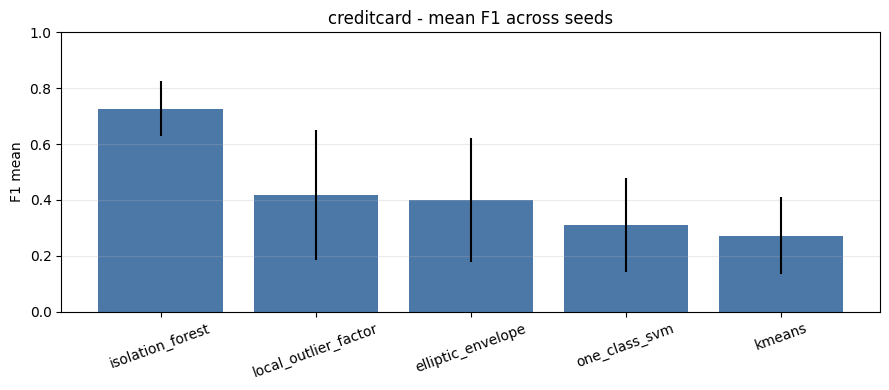

/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/pip/data_quality/notebooks/ml_profile_eval_utils.py:198: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-15.716170436445498' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_corrupted.loc[df_corrupted.index[idx], col] = col_mean + direction * scale * col_std
/home/ashahi/PFE/env/li


LOAN_APPROVAL


/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
0,mixed_structured,isolation_forest,0.541667,0.172516,0.541667,0.172516,0.541667,0.172516,3.000,3.0
1,mixed_structured,elliptic_envelope,0.354167,0.314182,0.375000,0.330344,0.363095,0.319882,2.875,3.0
2,mixed_structured,one_class_svm,0.262500,0.244584,0.458333,0.434157,0.333333,0.311805,4.625,3.0
3,mixed_structured,kmeans,0.291667,0.278174,0.291667,0.278174,0.291667,0.278174,3.000,3.0
4,mixed_structured,local_outlier_factor,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,3.0


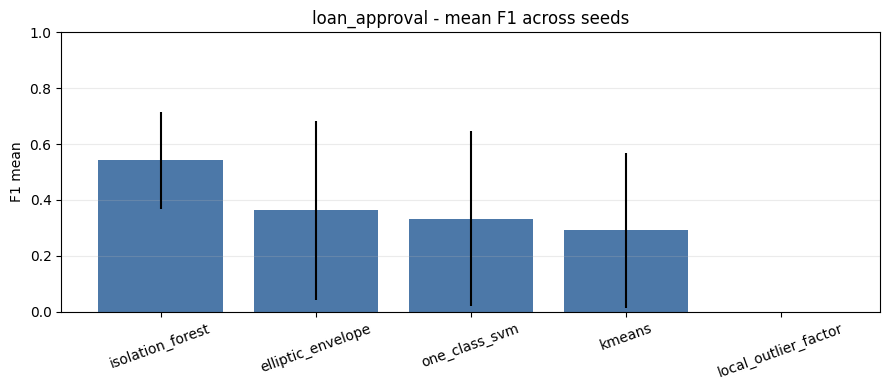

/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(
/home/ashahi/PFE/pip/data_quality/notebooks/ml_profile_eval_utils.py:198: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-3.9393209146341817' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_corrupted.loc[df_corrupted.index[idx], col] = col_mean + direction * scale * col_std
/home/ashahi/PFE/env/li


TELCO_CHURN


/home/ashahi/PFE/env/lib/python3.10/site-packages/sklearn/covariance/_robust_covariance.py:753: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
0,categorical_text,kmeans,0.250000,0.188982,0.333333,0.251976,0.285714,0.215980,4.000,3.0
1,categorical_text,elliptic_envelope,0.197917,0.125495,0.250000,0.154303,0.220238,0.136923,3.875,3.0
2,categorical_text,one_class_svm,0.187500,0.159052,0.208333,0.172516,0.196429,0.163849,3.500,3.0
3,categorical_text,isolation_forest,0.125000,0.133631,0.166667,0.178174,0.142857,0.152721,4.000,3.0
4,categorical_text,local_outlier_factor,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,3.0


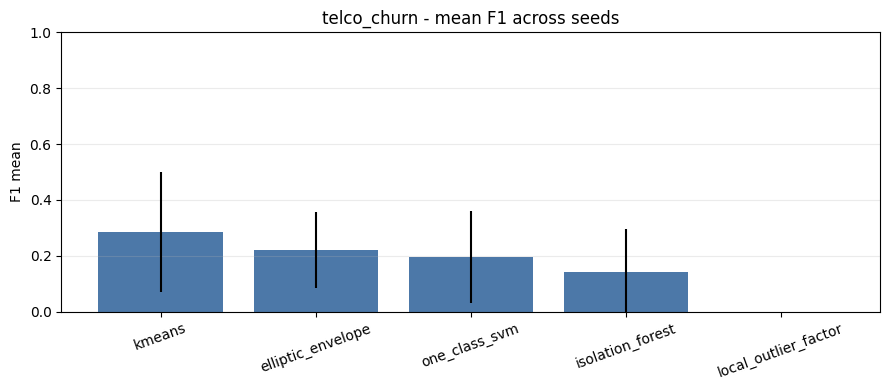

,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
10,categorical_text,kmeans,0.250000,0.188982,0.333333,0.251976,0.285714,0.215980,4.000,3.0
11,categorical_text,elliptic_envelope,0.197917,0.125495,0.250000,0.154303,0.220238,0.136923,3.875,3.0
12,categorical_text,one_class_svm,0.187500,0.159052,0.208333,0.172516,0.196429,0.163849,3.500,3.0
13,categorical_text,isolation_forest,0.125000,0.133631,0.166667,0.178174,0.142857,0.152721,4.000,3.0
14,categorical_text,local_outlier_factor,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,3.0
5,mixed_structured,isolation_forest,0.541667,0.172516,0.541667,0.172516,0.541667,0.172516,3.000,3.0
6,mixed_structured,elliptic_envelope,0.354167,0.314182,0.375000,0.330344,0.363095,0.319882,2.875,3.0
7,mixed_structured,one_class_svm,0.262500,0.244584,0.458333,0.434157,0.333333,0.311805,4.625,3.0
8,mixed_structured,kmeans,0.291667,0.278174,0.291667,0.278174,0.291667,0.278174,3.000,3.0
9,mixed_structured,local_outlier_factor,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,3.0


,family,model,f1_mean,f1_std,precision_mean,recall_mean,detected_mean
2,categorical_text,kmeans,0.285714,0.215980,0.250000,0.333333,4.000
0,categorical_text,elliptic_envelope,0.220238,0.136923,0.197917,0.250000,3.875
4,categorical_text,one_class_svm,0.196429,0.163849,0.187500,0.208333,3.500
1,categorical_text,isolation_forest,0.142857,0.152721,0.125000,0.166667,4.000
3,categorical_text,local_outlier_factor,0.000000,0.000000,0.000000,0.000000,0.000
6,mixed_structured,isolation_forest,0.541667,0.172516,0.541667,0.541667,3.000
5,mixed_structured,elliptic_envelope,0.363095,0.319882,0.354167,0.375000,2.875
9,mixed_structured,one_class_svm,0.333333,0.311805,0.262500,0.458333,4.625
7,mixed_structured,kmeans,0.291667,0.278174,0.291667,0.291667,3.000
8,mixed_structured,local_outlier_factor,0.000000,0.000000,0.000000,0.000000,0.000


In [11]:
all_summaries = []
all_details = []
all_benchmarks = []

for spec in DATASET_SPECS:
    summary, detail, benchmark = benchmark_spec(spec, CANDIDATE_MODELS, seeds=range(8))
    print(f'\n{spec.name.upper()}')
    display(summary)
    fig, ax = build_f1_plot(summary, f'{spec.name} - mean F1 across seeds')
    plt.show()
    all_summaries.append(summary)
    all_details.append(detail)
    all_benchmarks.append(benchmark)

overall_summary = pd.concat(all_summaries, ignore_index=True)
overall_detail = pd.concat(all_details, ignore_index=True)
overall_benchmark = pd.concat(all_benchmarks, ignore_index=True)

display(overall_summary.sort_values(['family', 'f1_mean', 'precision_mean', 'recall_mean'], ascending=[True, False, False, False]))
display(overall_detail.groupby(['family', 'model'], as_index=False).agg(
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
    precision_mean=('precision', 'mean'),
    recall_mean=('recall', 'mean'),
    detected_mean=('detected_anomalies', 'mean'),
).sort_values(['family', 'f1_mean'], ascending=[True, False]))


In [12]:
champions = select_family_champions(overall_summary)
display(champions)

registry = {
    'generated_at': pd.Timestamp.utcnow().isoformat(),
    'feature_cols': None,
    'families': [],
}

artifact_paths = {}

for _, row in champions.iterrows():
    spec = next(spec for spec in DATASET_SPECS if spec.family == row['family'])
    df = drop_protected_columns(load_dataset(spec.path), spec.protected_columns)
    clean_profile = build_profile_frame(df, spec.name)
    detector = train_detector(
        clean_profile,
        family=spec.family,
        model_name=row['model'],
        contamination=spec.anomaly_rate,
    )
    artifact_path = save_detector(detector, ARTIFACTS_DIR, dataset_name=spec.name)
    artifact_paths[spec.family] = str(artifact_path)
    registry['feature_cols'] = detector.feature_cols
    registry['families'].append({
        'family': spec.family,
        'dataset_name': spec.name,
        'model_name': row['model'],
        'artifact_path': str(artifact_path),
        'protected_columns': list(spec.protected_columns),
        'anomaly_rate': spec.anomaly_rate,
        'metrics': row.to_dict(),
    })

summary_path = ARTIFACTS_DIR / 'model_summary.csv'
detail_path = ARTIFACTS_DIR / 'model_detail.csv'
benchmark_path = ARTIFACTS_DIR / 'model_benchmark.csv'

overall_summary.to_csv(summary_path, index=False)
overall_detail.to_csv(detail_path, index=False)
overall_benchmark.to_csv(benchmark_path, index=False)
registry_path = save_registry(registry, ARTIFACTS_DIR)

print(f'Registry saved to: {registry_path}')
print(f'Summary saved to: {summary_path}')
print(f'Detail saved to: {detail_path}')
print(f'Benchmark saved to: {benchmark_path}')
artifact_paths


,family,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,detected_mean,true_anomalies_mean
0,categorical_text,kmeans,0.250000,0.188982,0.333333,0.251976,0.285714,0.215980,4.0,3.0
1,mixed_structured,isolation_forest,0.541667,0.172516,0.541667,0.172516,0.541667,0.172516,3.0,3.0
2,numeric,isolation_forest,0.666667,0.089087,0.800000,0.106904,0.727273,0.097186,6.0,5.0


Registry saved to: /home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/model_registry.json
Summary saved to: /home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/model_summary.csv
Detail saved to: /home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/model_detail.csv
Benchmark saved to: /home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/model_benchmark.csv


{'categorical_text': '/home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/telco_churn_kmeans_detector.joblib',
 'mixed_structured': '/home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/loan_approval_isolation_forest_detector.joblib',
 'numeric': '/home/ashahi/PFE/pip/data_quality/notebooks/artifacts/ml_models/creditcard_isolation_forest_detector.joblib'}

## What this notebook gives you

- one champion detector per dataset family
- serialized artifacts ready for backend loading
- a registry file with metadata, chosen model names, and protected columns
- benchmark tables that you can cite in the literature review section to justify the hybrid approach

Next step in the application: load the family artifact during validation, run inference on the profiled columns, and merge its signal with the rule-based outputs from Deequ, Great Expectations, and Spark validators.
